In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

In [9]:
data= pd.read_csv("Exam_Score_Prediction.csv")

In [10]:
data.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [21]:
data["study_hours_cat"]= pd.cut(data["study_hours"], bins= [0,1,2,3,4,5,6,7,np.inf], labels= [1,2,3,4,5,6,7,8])

In [23]:
data.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,study_hours_cat
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9,3
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8,4
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3,8
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7,1
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7,1


In [36]:
data_num= data.drop(["age", "gender", "course", "internet_access", "sleep_quality", "study_method", "facility_rating", "exam_difficulty", "study_hours_cat"], axis=1)

In [38]:
data_num.corr()

,student_id,study_hours,class_attendance,sleep_hours,exam_score
student_id,1.000000,0.002116,0.001128,-0.000560,0.003269
study_hours,0.002116,1.000000,-0.001645,-0.004533,0.717788
class_attendance,0.001128,-0.001645,1.000000,0.007187,0.308850
sleep_hours,-0.000560,-0.004533,0.007187,1.000000,0.133222
exam_score,0.003269,0.717788,0.308850,0.133222,1.000000


In [39]:
from pandas.plotting import scatter_matrix

array([[<Axes: xlabel='student_id', ylabel='student_id'>,
        <Axes: xlabel='study_hours', ylabel='student_id'>,
        <Axes: xlabel='class_attendance', ylabel='student_id'>,
        <Axes: xlabel='sleep_hours', ylabel='student_id'>,
        <Axes: xlabel='exam_score', ylabel='student_id'>],
       [<Axes: xlabel='student_id', ylabel='study_hours'>,
        <Axes: xlabel='study_hours', ylabel='study_hours'>,
        <Axes: xlabel='class_attendance', ylabel='study_hours'>,
        <Axes: xlabel='sleep_hours', ylabel='study_hours'>,
        <Axes: xlabel='exam_score', ylabel='study_hours'>],
       [<Axes: xlabel='student_id', ylabel='class_attendance'>,
        <Axes: xlabel='study_hours', ylabel='class_attendance'>,
        <Axes: xlabel='class_attendance', ylabel='class_attendance'>,
        <Axes: xlabel='sleep_hours', ylabel='class_attendance'>,
        <Axes: xlabel='exam_score', ylabel='class_attendance'>],
       [<Axes: xlabel='student_id', ylabel='sleep_hours'>,
        <

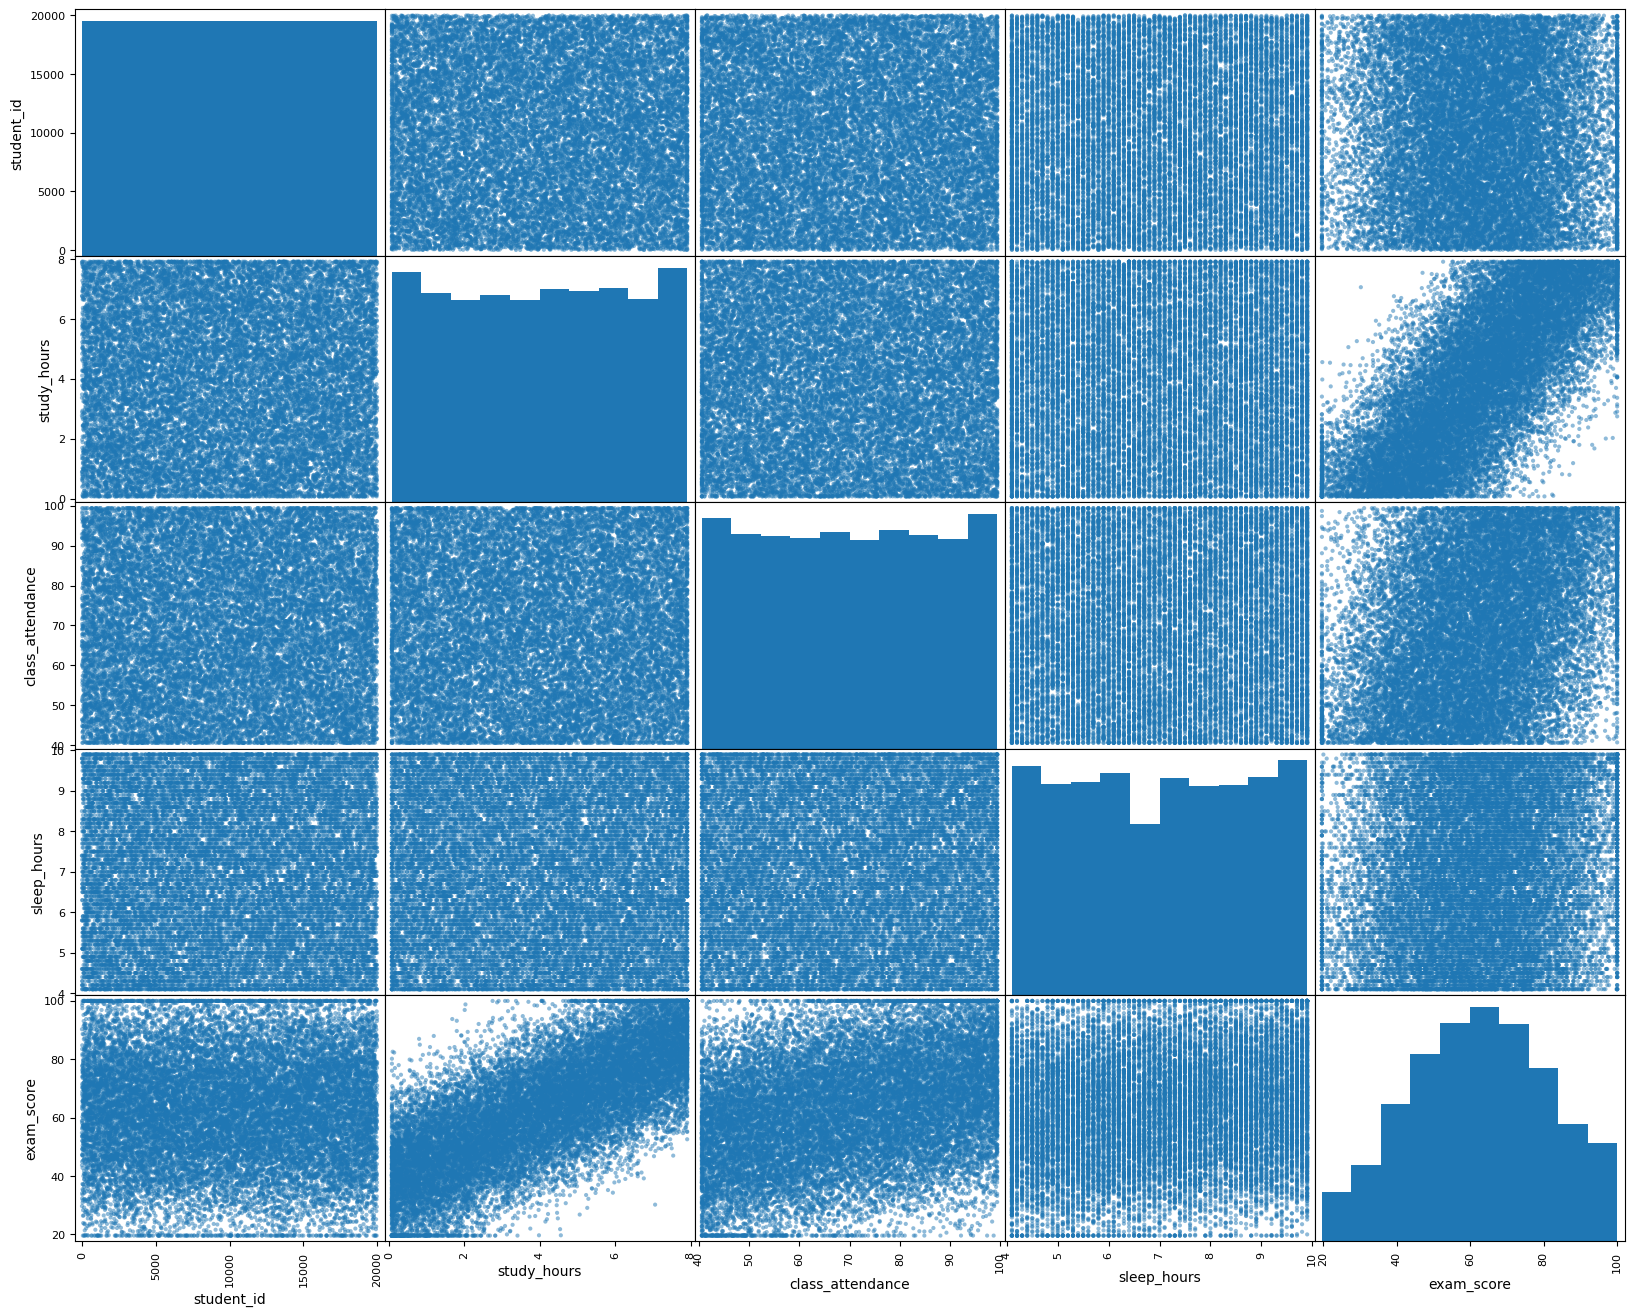

In [40]:
attributes= ["student_id", "study_hours", "class_attendance", "sleep_hours", "exam_score"]
scatter_matrix(data_num[attributes], figsize= (20,16))

In [24]:
split= StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(data, data["study_hours_cat"]):
    strat_train_set= data.loc[train_index].drop("study_hours_cat", axis=1)
    strat_test_set= data.loc[test_index].drop("study_hours_cat", axis=1)

In [26]:
set(data["study_method"])

{'coaching', 'group study', 'mixed', 'online videos', 'self-study'}

In [30]:
exam_score= strat_train_set["exam_score"].copy()

In [31]:
exam_parameters= strat_train_set.drop("exam_score", axis=1)

In [33]:
set(exam_parameters["age"])

{17, 18, 19, 20, 21, 22, 23, 24}